# Author countries — Validation & Visualization (OpenAlex)

Face-validity figures for `OpenAlex/output/paper_author_country.parquet`, the author-country
table written by `OpenAlex/notebook/paper_author_country.ipynb`, read against the sibling
metric tables of the same pipeline:

1. **Coverage** — which papers have a located author, by publication year and by team size.
2. **Country composition over time** — the largest producers' share of located papers, under
   full and fractional counting.
3. **International collaboration** — share of multi-country papers by year and team size.
4. **Internationality, impact and disruption** — citation percentile and CD by number of
   countries, *within* team-size bands (Wagner et al. 2017; Wu et al. 2019).
5. **Country pairs** — who collaborates with whom, 2015–2020.
6. **Country profiles** — internationality against impact and disruption, top 30 producers.
7. **Cross-check against Dimensions** — the same quantities from an independent index.
8. **First and last author** — how often the two ends of the byline sit in the same country.

## What the country of a paper is here
`countries` is the set of ISO2 codes of the institutions the paper's affiliations resolved to,
one row per paper, de-duplicated by author. A paper is **located** when at least one author
resolved; **international** when the located authors span ≥ 2 countries. Coverage is therefore a
property of OpenAlex's affiliation matching, not of the paper: §1 measures it before any section
conditions on it, and every later share is taken over located papers so that a rising coverage
curve cannot be mistaken for a rising collaboration rate.

An author with two affiliations in different countries contributes to **both** entries of
`country_author_counts`, so those counts can sum to more than `n_located`. Fractional counting in
§2 divides by that sum, which is the standard convention.

## Inputs
`paper_author_country`, `paper_metadata` (year, field), `paper_hit_probability` (`pctl_c10`),
`paper_disruption` (`CD_5`), `paper_citation` (`C_10`). §7 additionally reads
`Dimensions/output/{paper_author, paper_metadata}.parquet` and is skipped if they are absent.

§0 joins those into one row per paper at `validation/data/author_country_base.parquet` and every
later section reads that; delete the file to force a rebuild. **Not a login-node notebook** — the
join spans 250M–370M-row tables. Smoke test: `NB_BASE_LIMIT=200000 NB_BASE_FP=/tmp/x.parquet`.

In [1]:
import os, sys, time, duckdb
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.dpi'] = 110

sys.path.insert(0, '/project/jevans/Dawoon/Science of Science/validation')
import val_common as V
V.init('author_country_validation'); V.preflight()

P = V.paper
AC   = P('paper_author_country.parquet')
META = P('paper_metadata.parquet')
HIT  = P('paper_hit_probability.parquet')
DISR = P('paper_disruption.parquet')
CIT  = P('paper_citation.parquet')
DIM_AU, DIM_META = V.dim('paper_author.parquet'), V.dim('paper_metadata.parquet')

# The joined per-paper table. NB_BASE_LIMIT builds it from the first N papers instead of all
# 251.7M, which is what makes a smoke test of every query below take seconds.
BASE_FP    = os.environ.get('NB_BASE_FP', f'{V.VAL}/data/author_country_base.parquet')
BASE_LIMIT = int(os.environ['NB_BASE_LIMIT']) if os.environ.get('NB_BASE_LIMIT') else None
YMIN, YMAX = 1950, 2025

con = duckdb.connect()
con.execute(f"SET memory_limit='{os.environ.get('NB_DUCKDB_MEM', '150GB')}'")
con.execute(f"SET temp_directory='{V.TMP}'")
con.execute("SET preserve_insertion_order=false")
con.execute("SET enable_progress_bar=false")
print(f'base table : {BASE_FP}' + (f'   *** SMOKE: first {BASE_LIMIT:,} papers' if BASE_LIMIT else ''))

C1, C2, C3, C4 = '#4E2A84', '#F7602A', '#2a78d6', '#3aa17e'      # the palette the sibling validation notebooks use
# Magnitude is a SINGLE hue, light -> dark; polarity is two opposite-temperature hues with a
# neutral middle. No rainbow ramp anywhere: on a choropleth a multi-hue ramp invents regions.
SEQ, DIV = 'Blues', 'RdBu_r'
# NODATA has to be told apart from BOTH the pale end of the sequential ramp and the near-white
# middle of the diverging one, so it is a grey with no blue in it rather than a light tint.
INK, MUTED, NODATA, LAND = '#1f2933', '#6b7280', '#cfd2d6', '#dfe4ea'
BANDS = [(2, 3, '2-3'), (4, 6, '4-6'), (7, 10, '7-10'), (11, 10**6, '11+')]
BAND_ORDER = [l for _, _, l in BANDS]
BAND_SQL = "CASE " + " ".join(f"WHEN team_size BETWEEN {a} AND {b} THEN '{l}'" for a, b, l in BANDS) + " END"

def clean(ax):
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False); ax.grid(alpha=0.25)

def ci95(std, n):
    """95% CI half-width of a mean. std/n come straight from SQL, so both can be null."""
    std = pd.to_numeric(std, errors='coerce').fillna(0).to_numpy(float)
    n = pd.to_numeric(n, errors='coerce').fillna(0).to_numpy(float)
    return 1.96 * std / np.sqrt(np.maximum(n, 1))

def pair_heatmap(pairs, top, title, ax, cbar_label="% of A's international documents with B"):
    """pairs: DataFrame (c1, c2, n) over UNORDERED pairs, c1 < c2.

    Row-normalised, so the matrix is NOT symmetric: cell (A, B) is the share of A's
    international documents that involve B. Reading it the other way round would say that a
    small country and the US collaborate equally often, which is the opposite of the fact.
    """
    top = list(top)
    m = pd.DataFrame(0.0, index=top, columns=top)
    tot = {}
    for c1, c2, n in pairs[['c1', 'c2', 'n']].itertuples(index=False):
        tot[c1] = tot.get(c1, 0) + n
        tot[c2] = tot.get(c2, 0) + n
        if c1 in m.index and c2 in m.columns:
            m.loc[c1, c2] += n
            m.loc[c2, c1] += n
    share = m.div(pd.Series({c: tot.get(c, 1) or 1 for c in top}), axis=0) * 100
    im = ax.imshow(share.to_numpy(), cmap=SEQ, aspect='auto')
    ax.set_xticks(range(len(top))); ax.set_xticklabels(top, rotation=90, fontsize=8)
    ax.set_yticks(range(len(top))); ax.set_yticklabels(top, fontsize=8)
    vals = share.to_numpy()
    hi = vals.max() or 1
    for i in range(len(top)):
        for j in range(len(top)):
            # ink on the light end, white on the dark end -- one fixed colour would be
            # unreadable at one end of a light-to-dark ramp
            if i != j and vals[i, j] >= 8:
                ax.text(j, i, f'{vals[i, j]:.0f}', ha='center', va='center', fontsize=6,
                        color=('white' if vals[i, j] > 0.55 * hi else INK))
    ax.set_title(title, fontsize=10); ax.set_ylabel('country A'); ax.set_xlabel('partner B')
    plt.colorbar(im, ax=ax, fraction=0.04, label=cbar_label)
    return share

def spearman(a, b):
    from scipy.stats import spearmanr
    return spearmanr(a, b).correlation


# --- world maps -------------------------------------------------------------------------
# Boundaries: validation/data/world_countries.geojson, Natural Earth 1:50m Admin 0 (public
# domain), trimmed to iso2/name/continent and simplified; see world_countries.source.json.
# The 1:50m cut is deliberate -- 1:110m omits Singapore, Hong Kong, Malta and Bahrain, all of
# which are real producers here, and a country missing from the map reads as a country with no
# output. Robinson, because an equirectangular world map inflates the high latitudes and this
# figure is about how much each country produces.
WORLD_FP = f'{V.VAL}/data/world_countries.geojson'
ROBINSON = '+proj=robin +lon_0=0 +datum=WGS84 +units=m +no_defs'

def load_world():
    """(GeoDataFrame in Robinson, {iso2: (lon, lat)}) or (None, None) if the file is absent."""
    try:
        import geopandas as gpd
    except ImportError:
        print('geopandas is not installed -- map sections skipped'); return None, None
    if not os.path.exists(WORLD_FP):
        print(f'{WORLD_FP} is missing -- map sections skipped.\n'
              '  Rebuild it from Natural Earth 1:50m Admin 0 Countries; see world_countries.source.json.')
        return None, None
    w = gpd.read_file(WORLD_FP)

    def rep(g):
        # the representative point of the LARGEST polygon, so the United States lands in the
        # lower 48 and France in France rather than in Alaska or French Guiana
        p = max(g.geoms, key=lambda q: q.area) if g.geom_type == 'MultiPolygon' else g
        return p.representative_point()

    pts = {r.iso2: (rep(r.geometry).x, rep(r.geometry).y) for r in w.itertuples()}
    return w.to_crs(ROBINSON), pts

def frame(ax, world):
    """Every panel gets the same extent, so the four maps are comparable and a stray arc is clipped."""
    x0, y0, x1, y1 = world.total_bounds
    mx, my = 0.02 * (x1 - x0), 0.04 * (y1 - y0)
    ax.set_xlim(x0 - mx, x1 + mx); ax.set_ylim(y0 - my, y1 + my)
    ax.set_axis_off()

def choropleth(ax, world, values, title, label, cmap=SEQ, norm=None):
    """values: Series indexed by ISO2. Countries with no value are drawn in the no-data grey."""
    g = world.merge(values.rename('v'), left_on='iso2', right_index=True, how='left')
    g.plot(ax=ax, column='v', cmap=cmap, norm=norm, linewidth=0.2, edgecolor='white',
           legend=True, legend_kwds={'orientation': 'horizontal', 'shrink': 0.62, 'pad': 0.01,
                                     'aspect': 34, 'label': label},
           missing_kwds={'color': NODATA, 'edgecolor': 'white', 'linewidth': 0.2})
    ax.set_title(title, fontsize=10, color=INK); frame(ax, world)
    return g

def map_coverage(values, world, what):
    """Say out loud which codes in the data have no polygon, and how much output they carry."""
    have = set(world['iso2'])
    miss = values[[c not in have for c in values.index]]
    if len(miss):
        share = 100 * miss.sum() / values.sum() if values.sum() else 0
        print(f'  {len(miss)} {what} code(s) have no polygon on the map '
              f'({share:.2f}% of the total): {", ".join(sorted(miss.index)[:20])}')
    else:
        print(f'  every {what} code in the data is on the map')

def flowmap(ax, world, pts, pairs, title, topn=70, label_top=10):
    """Great-circle arcs between country representative points, width ~ sqrt(volume)."""
    import geopandas as gpd
    from shapely.geometry import LineString
    from pyproj import Geod
    geod = Geod(ellps='WGS84')
    world.plot(ax=ax, color=LAND, edgecolor='white', linewidth=0.35)
    top = pairs.nlargest(topn, 'n')
    segs, wts, dropped = [], [], 0
    for c1, c2, n in top[['c1', 'c2', 'n']].itertuples(index=False):
        if c1 not in pts or c2 not in pts:
            dropped += 1; continue
        (x1, y1), (x2, y2) = pts[c1], pts[c2]
        coords = [(x1, y1)] + geod.npts(x1, y1, x2, y2, 60) + [(x2, y2)]
        run = [coords[0]]
        for p, q in zip(coords, coords[1:]):
            if abs(q[0] - p[0]) > 180:          # the arc crosses the antimeridian: cut it
                if len(run) > 1: segs.append(LineString(run)); wts.append(n)
                run = [q]
            else:
                run.append(q)
        if len(run) > 1: segs.append(LineString(run)); wts.append(n)
    if not segs:
        print('  no drawable pairs'); return
    gl = gpd.GeoDataFrame({'n': wts}, geometry=segs, crs='EPSG:4326').to_crs(ROBINSON)
    hi = gl.n.max()
    gl.plot(ax=ax, color=C1, linewidth=0.35 + 3.6 * np.sqrt(gl.n / hi), alpha=0.45)
    deg = pd.concat([top.groupby('c1').n.sum(), top.groupby('c2').n.sum()]).groupby(level=0).sum()
    named = gpd.GeoSeries.from_xy(*zip(*[pts[c] for c in deg.nlargest(label_top).index
                                         if c in pts]), crs='EPSG:4326').to_crs(ROBINSON)
    for code, p in zip([c for c in deg.nlargest(label_top).index if c in pts], named):
        ax.plot(p.x, p.y, 'o', ms=3, color=INK, zorder=5)
        ax.annotate(code, (p.x, p.y), fontsize=8, color=INK, zorder=6,
                    xytext=(4, 3), textcoords='offset points')
    ax.set_title(title, fontsize=10, color=INK)
    # A near-antipodal pair has a great circle that sweeps over a pole and far outside the
    # Robinson outline; clipping to the map keeps the map the size of the map.
    frame(ax, world)
    if dropped:
        print(f'  {dropped} of the top {topn} pairs involve a country with no polygon and are not drawn')

[val] author_country_validation  ->  /project/jevans/Dawoon/Science of Science/validation/Figures/author_country_validation_<section>.{jpg,pdf}  @ 600 dpi
  author_country_validationOK
base table : /project/jevans/Dawoon/Science of Science/validation/data/author_country_base.parquet


## 0. Base table and integrity

One row per paper of `paper_author_country`, with the publication year and field from
`paper_metadata`, the within-(field, year) 10-year citation percentile from
`paper_hit_probability`, `CD_5` from `paper_disruption` and `C_10` from `paper_citation`.
Left joins throughout: a paper missing from a metric table keeps its country columns and drops
out of that metric's figures only.

The counts printed below are also three assertions — `n_located ≤ team_size`, `n_countries` and
`countries` agreeing on emptiness, and `n_countries` equal to the length of the split list. They
duplicate the producer notebook's own checks on purpose: this notebook is the consumer, and a
consumer that trusts its input cannot detect a regression in it.

In [2]:
%%time
if not os.path.exists(BASE_FP):
    t0 = time.time()
    os.makedirs(os.path.dirname(BASE_FP), exist_ok=True)
    src = f"read_parquet('{AC}')" if not BASE_LIMIT else f"(SELECT * FROM read_parquet('{AC}') LIMIT {BASE_LIMIT})"
    con.execute(f"""
    COPY (
      SELECT a.paper_id,
             m.year::INTEGER                                      AS year,
             coalesce(m.FoS_rep, split_part(m.FoS_0, ';', 1))      AS FoS,
             a.team_size, a.n_located, a.n_countries, a.countries, a.country_author_counts,
             a.first_author_country, a.last_author_country,
             h.pctl_c10, d.CD_5, c.C_10
      FROM {src} a
      LEFT JOIN read_parquet('{META}') m USING (paper_id)
      LEFT JOIN read_parquet('{HIT}')  h USING (paper_id)
      LEFT JOIN read_parquet('{DISR}') d USING (paper_id)
      LEFT JOIN read_parquet('{CIT}')  c USING (paper_id)
    ) TO '{BASE_FP}.tmp' (FORMAT PARQUET, COMPRESSION ZSTD, ROW_GROUP_SIZE 1000000)""")
    os.replace(BASE_FP + '.tmp', BASE_FP)
    print(f'base table built in {time.time()-t0:.0f}s  ({os.path.getsize(BASE_FP)/1e9:.2f} GB)')
else:
    print(f'base table present ({os.path.getsize(BASE_FP)/1e9:.2f} GB) -- delete it to rebuild')

B = f"read_parquet('{BASE_FP}')"
s = con.execute(f"""
SELECT count(*) AS papers, count(year) AS with_year, sum(team_size) AS author_slots, sum(n_located) AS located_slots,
       count(countries) AS with_country, count(*) FILTER (WHERE n_countries > 1) AS international,
       count(pctl_c10) AS with_hit, count(CD_5) AS with_cd5, count(C_10) AS with_c10,
       count(*) FILTER (WHERE n_located > team_size)                                        AS bad_located,
       count(*) FILTER (WHERE (n_countries > 0) <> (countries IS NOT NULL))                 AS bad_country_flag,
       count(*) FILTER (WHERE countries IS NOT NULL AND n_countries <> len(str_split(countries, ';'))) AS bad_n_countries
FROM {B}""").fetchdf().iloc[0]
for k, v in s.items():
    print(f'  {k:<18} {int(v):>15,}')
ok = s.bad_located == 0 and s.bad_country_flag == 0 and s.bad_n_countries == 0
print(f"\n  located papers {s.with_country/s.papers*100:.1f}%   located author slots {s.located_slots/s.author_slots*100:.1f}%   "
      f"international {s.international/s.papers*100:.1f}%")
print(f"  integrity of the input table: {'ALL PASS' if ok else 'FAILED -- see bad_* above'}")

base table present (3.17 GB) -- delete it to rebuild


  papers                 251,654,553
  with_year              176,996,555
  author_slots           738,442,925
  located_slots          395,233,376
  with_country           112,317,897
  international           18,169,845
  with_hit               161,972,727
  with_cd5                77,482,066
  with_c10               176,996,541
  bad_located                      0
  bad_country_flag                 0
  bad_n_countries                  0

  located papers 44.6%   located author slots 53.5%   international 7.2%
  integrity of the input table: ALL PASS
CPU times: user 23 s, sys: 482 ms, total: 23.5 s
Wall time: 5.17 s


## 1. Coverage — which papers have a country at all

Left: share of papers with ≥ 1 located author, and share of author *slots* located, by
publication year. Right: the same two by team size, 1990 onwards.

Both curves should rise with time and with team size, for the same reason: an affiliation
string has to exist and has to match an institution, and older and smaller papers carry fewer
strings. The gap between the two curves is informative — papers rise faster than slots, because
one located author is enough to locate a paper.

  [fig] author_country_validation_1.jpg + .pdf  (600 dpi)


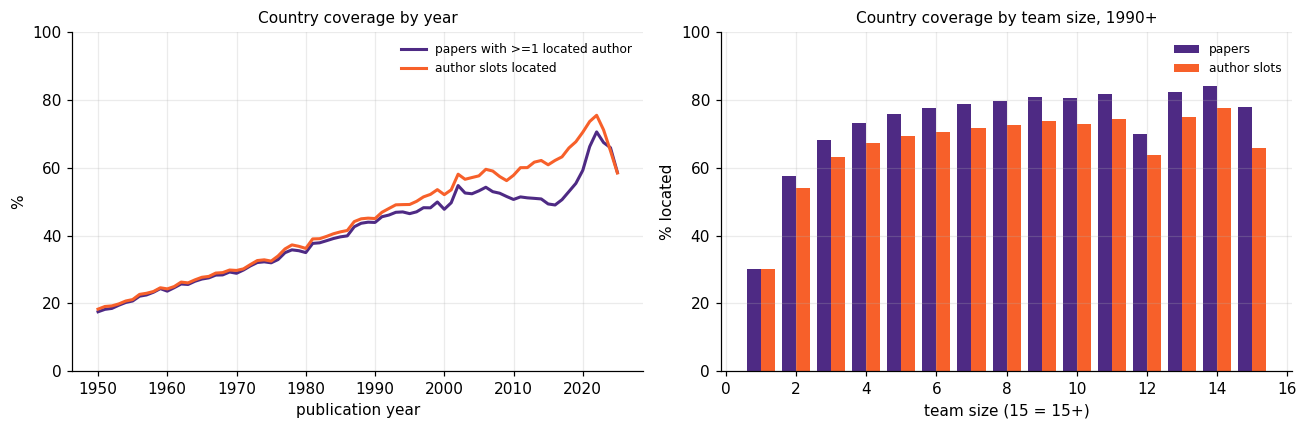

            n  pct_papers  pct_slots
year                                
1950   193230        17.5       18.3
1970   680989        28.9       29.7
1990  1364955        43.9       45.0
2000  2206112        47.8       52.1
2010  4691163        50.7       57.8
2020  8331320        59.2       70.5
CPU times: user 12.6 s, sys: 369 ms, total: 12.9 s
Wall time: 3.26 s


In [3]:
%%time
cov_y = con.execute(f"""
SELECT year, count(*) AS n, 100.0*count(countries)/count(*) AS pct_papers,
       100.0*sum(n_located)/nullif(sum(team_size), 0) AS pct_slots
FROM {B} WHERE year BETWEEN {YMIN} AND {YMAX} GROUP BY 1 ORDER BY 1""").fetchdf()
cov_t = con.execute(f"""
SELECT least(team_size, 15) AS team_size, count(*) AS n, 100.0*count(countries)/count(*) AS pct_papers,
       100.0*sum(n_located)/nullif(sum(team_size), 0) AS pct_slots
FROM {B} WHERE year BETWEEN 1990 AND {YMAX} GROUP BY 1 ORDER BY 1""").fetchdf()

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(cov_y.year, cov_y.pct_papers, color=C1, lw=2, label='papers with >=1 located author')
ax[0].plot(cov_y.year, cov_y.pct_slots, color=C2, lw=2, label='author slots located')
ax[0].set_xlabel('publication year'); ax[0].set_ylabel('%'); ax[0].set_ylim(0, 100)
ax[0].legend(frameon=False, fontsize=8); clean(ax[0]); ax[0].set_title('Country coverage by year', fontsize=10)
ax[1].bar(cov_t.team_size - 0.2, cov_t.pct_papers, 0.4, color=C1, label='papers')
ax[1].bar(cov_t.team_size + 0.2, cov_t.pct_slots, 0.4, color=C2, label='author slots')
ax[1].set_xlabel('team size (15 = 15+)'); ax[1].set_ylabel('% located'); ax[1].set_ylim(0, 100)
ax[1].legend(frameon=False, fontsize=8); clean(ax[1]); ax[1].set_title('Country coverage by team size, 1990+', fontsize=10)
V.save('1')
print(cov_y.set_index('year').reindex([y for y in (1950, 1970, 1990, 2000, 2010, 2020) if y in set(cov_y.year)]).round(1).to_string())

## 2. Country composition over time

**Full counting** credits a paper to every country on it, so the shares sum to more than 100%.
**Fractional counting** splits each paper across its located author slots, so they sum to 100%
and a country is credited for the share of the work its authors did.

Left: the twelve largest producers by year, full counting, as a share of located papers. Right:
full against fractional share for the top 20, 2010–2020. A country whose full share exceeds its
fractional share by a wide margin joins other countries' papers more often than it carries them —
which is what internationalisation looks like from the country side.

  [fig] author_country_validation_2.jpg + .pdf  (600 dpi)


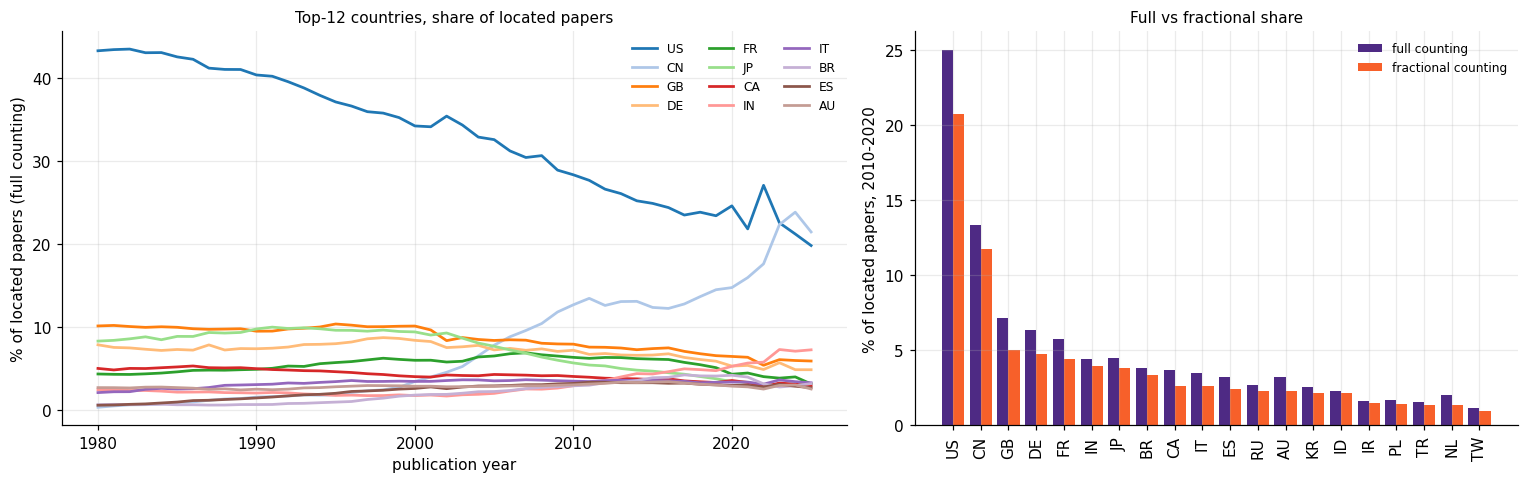

country  full_share  frac_share
     US       25.03       20.73
     CN       13.32       11.78
     GB        7.15        5.03
     DE        6.35        4.78
     FR        5.72        4.42
     IN        4.41        3.94
     JP        4.50        3.82
     BR        3.79        3.34
     CA        3.66        2.63
     IT        3.47        2.58
     ES        3.20        2.40
     RU        2.69        2.28
     AU        3.19        2.26
     KR        2.58        2.18
     ID        2.27        2.17
     IR        1.63        1.47
     PL        1.71        1.42
     TR        1.56        1.37
     NL        2.02        1.32
     TW        1.17        0.96
CPU times: user 6min 52s, sys: 4.69 s, total: 6min 57s
Wall time: 1min 12s


In [4]:
%%time
full = con.execute(f"""
SELECT year, c AS country, count(*) AS n
FROM {B}, unnest(str_split(countries, ';')) AS u(c)
WHERE countries IS NOT NULL AND year BETWEEN 1980 AND {YMAX} GROUP BY 1, 2""").fetchdf()
den = con.execute(f"""
SELECT year, count(countries) AS located FROM {B}
WHERE year BETWEEN 1980 AND {YMAX} GROUP BY 1 ORDER BY 1""").fetchdf().set_index('year')['located']
top12 = full[full.year.between(2000, 2020)].groupby('country').n.sum().nlargest(12).index.tolist()

# Fractional counting. country_author_counts is 'US:3;CN:1'; an author with two countries is in
# both entries, so the denominator is the sum of the counts, not n_located.
frac = con.execute(f"""
WITH x AS (
  SELECT list_transform(str_split(country_author_counts, ';'), s -> str_split(s, ':')) AS L
  FROM {B} WHERE country_author_counts IS NOT NULL AND year BETWEEN 2010 AND 2020),
y AS (SELECT L, list_sum(list_transform(L, z -> z[2]::INTEGER)) AS tot FROM x)
SELECT z[1] AS country, sum(z[2]::INTEGER / tot) AS frac_n, count(*) AS full_n
FROM y, unnest(L) AS u(z) WHERE tot > 0 GROUP BY 1""").fetchdf()
n_loc_1020 = con.execute(f"SELECT count(countries) FROM {B} WHERE year BETWEEN 2010 AND 2020").fetchone()[0]
frac['frac_share'] = 100 * frac.frac_n / frac.frac_n.sum()
frac['full_share'] = 100 * frac.full_n / max(n_loc_1020, 1)
top20 = frac.nlargest(20, 'frac_n')

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5), gridspec_kw={'width_ratios': [1.3, 1]})
cmap = plt.get_cmap('tab20')
for i, c in enumerate(top12):
    g = full[full.country == c].set_index('year').n.reindex(den.index)
    ax[0].plot(den.index, 100 * g / den, lw=1.8, color=cmap(i), label=c)
ax[0].set_xlabel('publication year'); ax[0].set_ylabel('% of located papers (full counting)')
ax[0].legend(ncol=3, fontsize=8, frameon=False); clean(ax[0])
ax[0].set_title('Top-12 countries, share of located papers', fontsize=10)
xs = np.arange(len(top20))
ax[1].bar(xs - 0.2, top20.full_share, 0.4, color=C1, label='full counting')
ax[1].bar(xs + 0.2, top20.frac_share, 0.4, color=C2, label='fractional counting')
ax[1].set_xticks(xs); ax[1].set_xticklabels(top20.country, rotation=90)
ax[1].set_ylabel('% of located papers, 2010-2020'); ax[1].legend(frameon=False, fontsize=8); clean(ax[1])
ax[1].set_title('Full vs fractional share', fontsize=10)
V.save('2')
print(top20[['country', 'full_share', 'frac_share']].round(2).to_string(index=False))

## 3. International collaboration

Share of papers whose located authors span ≥ 2 countries, over papers that have at least one
located author and at least two authors. Single-author papers are excluded: they can only be
"international" through one author with two affiliations, which is a different phenomenon and
would otherwise drag the whole series down as single-author papers become rarer.

The expected shape is a monotone rise from a few per cent in the 1970s — the most reproduced
result in the collaboration literature — and a rise with team size in the right-hand panel.

  [fig] author_country_validation_3.jpg + .pdf  (600 dpi)


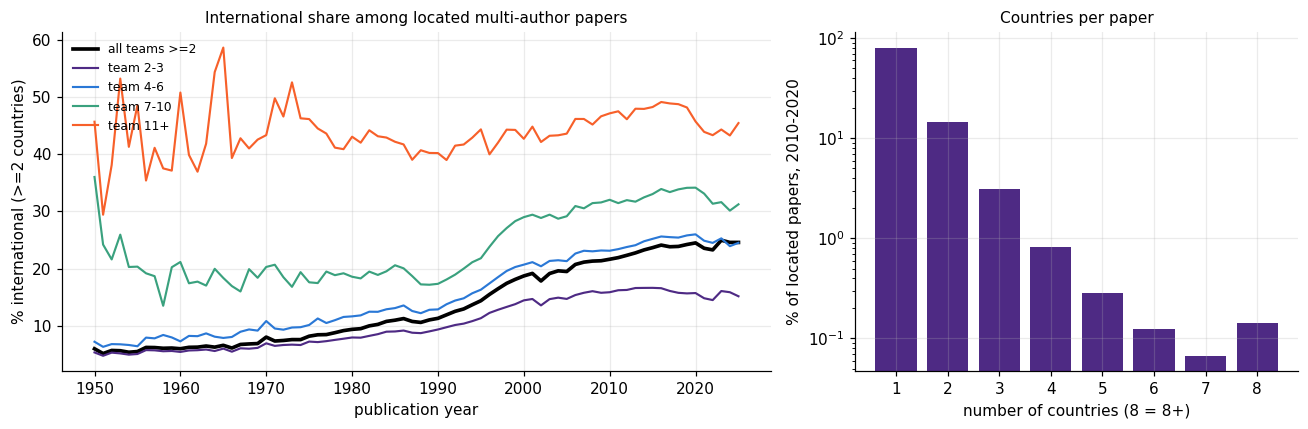

            n   pct
year               
1970   109813   8.0
1990   424766  11.3
2000   764908  18.7
2010  1835762  21.6
2020  3963954  24.5
CPU times: user 19.9 s, sys: 392 ms, total: 20.3 s
Wall time: 4.11 s


In [5]:
%%time
q_intl = """
SELECT year, {band} AS band, count(*) AS n, 100.0*count(*) FILTER (WHERE n_countries > 1)/count(*) AS pct
FROM {B} WHERE countries IS NOT NULL AND team_size >= 2 AND year BETWEEN {y0} AND {y1}
GROUP BY 1, 2 ORDER BY 1"""
intl_all = con.execute(q_intl.format(band="'all'", B=B, y0=YMIN, y1=YMAX)).fetchdf()
intl_band = con.execute(q_intl.format(band=BAND_SQL, B=B, y0=YMIN, y1=YMAX)).fetchdf()
dist = con.execute(f"""
SELECT least(n_countries, 8) AS k, count(*) AS n FROM {B}
WHERE countries IS NOT NULL AND year BETWEEN 2010 AND 2020 GROUP BY 1 ORDER BY 1""").fetchdf()

fig, ax = plt.subplots(1, 2, figsize=(12, 4), gridspec_kw={'width_ratios': [1.6, 1]})
ax[0].plot(intl_all.year, intl_all.pct, lw=2.4, color='black', label='all teams >=2')
for lab, col in zip(BAND_ORDER, [C1, C3, C4, C2]):
    g = intl_band[intl_band.band == lab]
    ax[0].plot(g.year, g.pct, lw=1.4, color=col, label=f'team {lab}')
ax[0].set_xlabel('publication year'); ax[0].set_ylabel('% international (>=2 countries)')
ax[0].legend(frameon=False, fontsize=8); clean(ax[0])
ax[0].set_title('International share among located multi-author papers', fontsize=10)
ax[1].bar(dist.k, 100 * dist.n / dist.n.sum(), color=C1)
ax[1].set_yscale('log'); ax[1].set_xlabel('number of countries (8 = 8+)')
ax[1].set_ylabel('% of located papers, 2010-2020'); clean(ax[1])
ax[1].set_title('Countries per paper', fontsize=10)
V.save('3')
print(intl_all.set_index('year').reindex([y for y in (1970, 1990, 2000, 2010, 2020) if y in set(intl_all.year)])[['n', 'pct']].round(1).to_string())

## 4. Internationality against impact and disruption

Mean within-(field, year) 10-year citation percentile, share in the top 10% of that cohort, and
mean `CD_5`, by the number of countries — **within team-size bands**, publication years
1990–2015 so the 10-year window has closed.

The band split is the whole point. More countries almost always means more authors, and team
size alone moves both outcomes (Wu et al. 2019: large teams develop, small teams disrupt). Only
inside a band does the country count carry information of its own. The expectation from Wagner
et al. (2017) is that impact still rises with countries within a band; whether disruption falls
is the open question this figure is drawn to answer.

  [fig] author_country_validation_4.jpg + .pdf  (600 dpi)


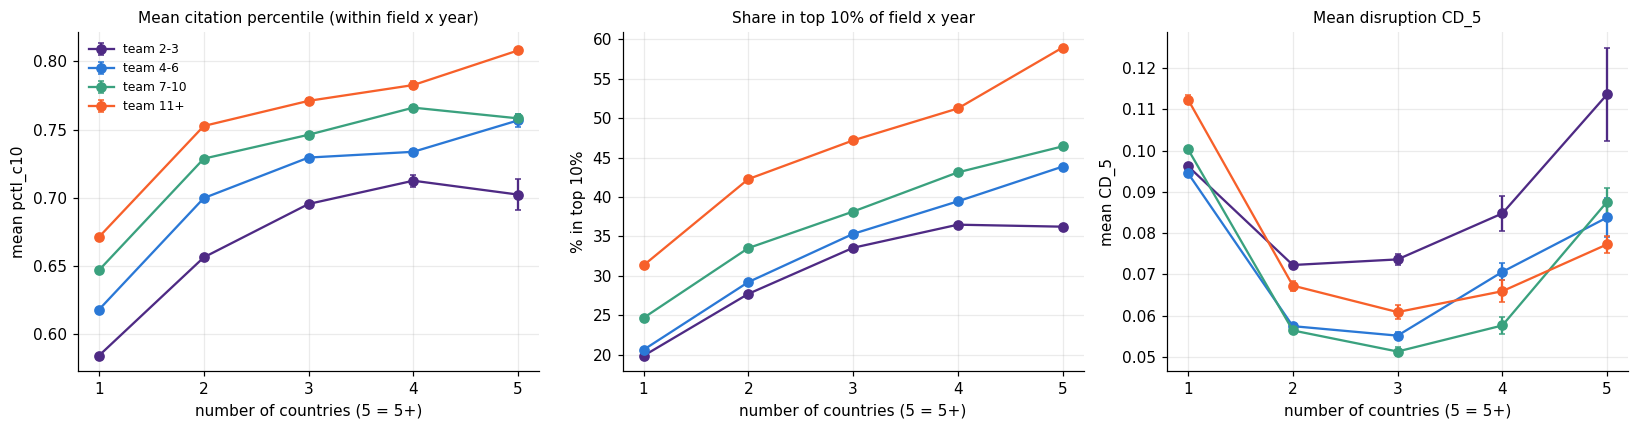

band     11+     2-3     4-6    7-10
k                                   
1     0.6712  0.5842  0.6179  0.6469
2     0.7526  0.6562  0.6997  0.7286
3     0.7711  0.6954  0.7294  0.7462
4     0.7826  0.7125  0.7337  0.7661
5     0.8081  0.7023  0.7567  0.7582

band     11+     2-3     4-6    7-10
k                                   
1     0.1123  0.0962  0.0945  0.1003
2     0.0673  0.0723  0.0575  0.0565
3     0.0609  0.0736  0.0552  0.0514
4     0.0659  0.0848  0.0706  0.0577
5     0.0773  0.1136  0.0838  0.0876
CPU times: user 11.5 s, sys: 422 ms, total: 11.9 s
Wall time: 3.08 s


In [6]:
%%time
imp = con.execute(f"""
SELECT {BAND_SQL} AS band, least(n_countries, 5) AS k, count(*) AS n,
       avg(pctl_c10) AS hit, stddev(pctl_c10) AS hit_sd,
       avg(CD_5) AS cd, stddev(CD_5) AS cd_sd, count(CD_5) AS n_cd,
       100.0*avg(CASE WHEN pctl_c10 >= 0.9 THEN 1.0 ELSE 0.0 END) AS top10
FROM {B}
WHERE countries IS NOT NULL AND team_size >= 2 AND year BETWEEN 1990 AND 2015 AND pctl_c10 IS NOT NULL
GROUP BY 1, 2 HAVING count(*) >= 500 ORDER BY 1, 2""").fetchdf()

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for lab, col in zip(BAND_ORDER, [C1, C3, C4, C2]):
    g = imp[imp.band == lab]
    if not len(g):
        continue
    ax[0].errorbar(g.k, g.hit, yerr=ci95(g.hit_sd, g.n), marker='o', color=col, label=f'team {lab}', capsize=2)
    ax[1].plot(g.k, g.top10, marker='o', color=col, label=f'team {lab}')
    ax[2].errorbar(g.k, g.cd, yerr=ci95(g.cd_sd, g.n_cd), marker='o', color=col, label=f'team {lab}', capsize=2)
for a, t, yl in zip(ax, ['Mean citation percentile (within field x year)', 'Share in top 10% of field x year',
                         'Mean disruption CD_5'],
                    ['mean pctl_c10', '% in top 10%', 'mean CD_5']):
    a.set_xlabel('number of countries (5 = 5+)'); a.set_ylabel(yl); a.set_title(t, fontsize=10)
    a.set_xticks([1, 2, 3, 4, 5]); clean(a)
ax[0].legend(frameon=False, fontsize=8)
V.save('4')
print(imp.pivot(index='k', columns='band', values='hit').round(4).to_string())
print()
print(imp.pivot(index='k', columns='band', values='cd').round(4).to_string())

## 5. Country pairs, 2015–2020

Every unordered pair of countries on a paper with 2–6 located countries (the cap keeps one
5,000-author collaboration from contributing 12M pairs). The heatmap is **row-normalised**: cell
(A, B) is the share of A's international papers that involve B, over the 15 countries with the
most international papers. It is deliberately asymmetric — most of a small country's
collaboration goes to the US, while a small share of the US's goes to it, and a symmetric matrix
would hide exactly that.

  [fig] author_country_validation_5.jpg + .pdf  (600 dpi)


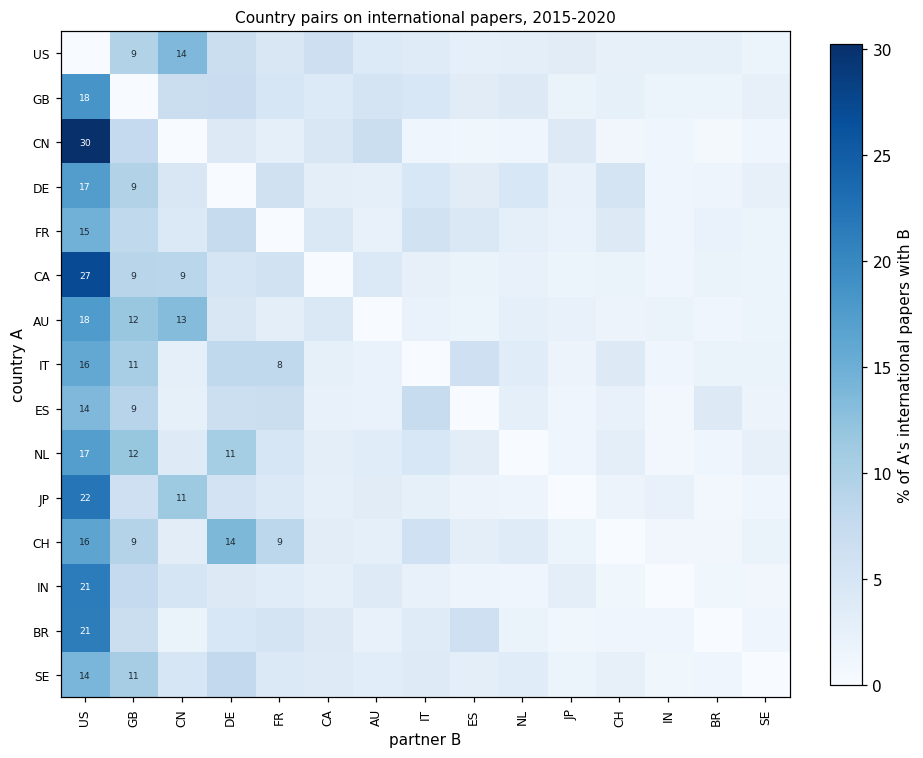

c1 c2      n
CN US 345311
GB US 238830
DE US 167501
CA US 162096
FR US 113715
AU US 102095
IT US  90827
DE GB  90755
CN GB  87205
JP US  86454
AU CN  75904
NL US  73862
KR US  73799
AU GB  68117
ES US  68043


CPU times: user 16 s, sys: 1.41 s, total: 17.4 s
Wall time: 6.42 s


In [7]:
%%time
pairs = con.execute(f"""
WITH p AS (
  SELECT paper_id, str_split(countries, ';') AS L
  FROM {B} WHERE year BETWEEN 2015 AND 2020 AND n_countries BETWEEN 2 AND 6),
e AS (SELECT paper_id, u.c AS c FROM p, unnest(p.L) AS u(c))
SELECT a.c AS c1, b.c AS c2, count(*) AS n
FROM e a JOIN e b ON a.paper_id = b.paper_id AND a.c < b.c
GROUP BY 1, 2""").fetchdf()
if not len(pairs):
    print('[skip 5] no international papers in 2015-2020 in this base table')
else:
    deg = pd.concat([pairs.groupby('c1').n.sum(), pairs.groupby('c2').n.sum()]).groupby(level=0).sum()
    top15 = deg.nlargest(15).index.tolist()
    fig, ax = plt.subplots(figsize=(8.5, 7))
    share5 = pair_heatmap(pairs, top15, 'Country pairs on international papers, 2015-2020', ax,
                          "% of A's international papers with B")
    V.save('5')
    print(pairs.nlargest(15, 'n').to_string(index=False))

## 6. Country profiles, 2000–2015

The 30 countries with the most located papers (full counting): international share against mean
citation percentile, and against mean `CD_5`. Marker area is proportional to the number of
papers.

Read the left panel as a check, not a finding: small, highly international, well-funded
countries should sit top-right, the US should sit apart — large, less international, still
highly cited — and any country far off that pattern is worth looking at before it is believed.

  [fig] author_country_validation_6.jpg + .pdf  (600 dpi)


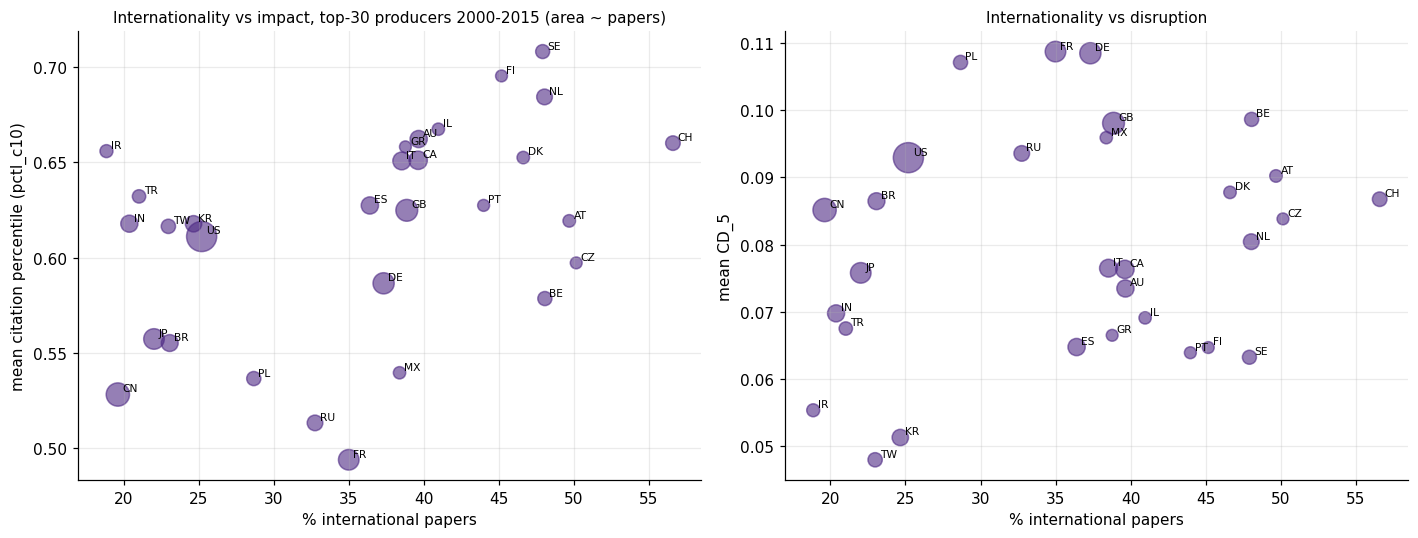

country       n   intl   team   hit    cd
     US 9668254 25.194  4.136 0.611 0.093
     CN 3455506 19.612  4.694 0.528 0.085
     GB 2662890 38.862  5.072 0.625 0.098
     DE 2364855 37.319  5.860 0.587 0.108
     JP 2105907 22.020  5.658 0.557 0.076
     FR 2103408 34.996  5.829 0.494 0.109
     CA 1329675 39.621  5.343 0.651 0.076
     IT 1182267 38.526  8.027 0.651 0.077
     ES 1036234 36.402  7.496 0.627 0.065
     AU 1024381 39.655  5.138 0.662 0.073
     IN  998611 20.376  5.003 0.618 0.070
     BR  952572 23.068  6.467 0.555 0.086
     KR  838313 24.655  6.624 0.618 0.051
     NL  712657 48.041  7.711 0.684 0.080
     RU  699561 32.747  8.416 0.513 0.094
     CH  526425 56.595 10.414 0.660 0.087
     TW  488572 22.978  8.476 0.616 0.048
     PL  473264 28.668  8.978 0.537 0.107
     BE  464577 48.062  7.022 0.579 0.099
     SE  449158 47.915  8.089 0.708 0.063
     TR  374353 21.023  9.047 0.632 0.068
     IR  331871 18.853  5.494 0.656 0.055
     AT  289721 49.686 11.695 0.61

In [8]:
%%time
prof = con.execute(f"""
WITH x AS (
  SELECT c AS country, n_countries, team_size, pctl_c10, CD_5
  FROM {B}, unnest(str_split(countries, ';')) AS u(c)
  WHERE countries IS NOT NULL AND year BETWEEN 2000 AND 2015)
SELECT country, count(*) AS n,
       100.0*avg(CASE WHEN n_countries > 1 THEN 1.0 ELSE 0.0 END) AS intl,
       avg(team_size) AS team, avg(pctl_c10) AS hit, avg(CD_5) AS cd
FROM x GROUP BY 1 ORDER BY n DESC LIMIT 30""").fetchdf()

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
for a, ycol, yl in zip(ax, ['hit', 'cd'], ['mean citation percentile (pctl_c10)', 'mean CD_5']):
    a.scatter(prof.intl, prof[ycol], s=np.sqrt(prof.n) / 8, color=C1, alpha=0.6)
    for _, r in prof.iterrows():
        a.annotate(r.country, (r.intl, r[ycol]), fontsize=7, xytext=(3, 2), textcoords='offset points')
    a.set_xlabel('% international papers'); a.set_ylabel(yl); clean(a)
ax[0].set_title('Internationality vs impact, top-30 producers 2000-2015 (area ~ papers)', fontsize=10)
ax[1].set_title('Internationality vs disruption', fontsize=10)
V.save('6')
print(prof.round(3).to_string(index=False))

## 7. Cross-check against Dimensions

`Dimensions/output/paper_author.parquet` carries a `countries` column built from the affiliation
*addresses* of a different index, by different code. Left: located share by year on both. Right:
top-15 country shares of located papers, 2010–2020, full counting, side by side, with the rank
correlation over every country present in both.

The **levels are not expected to match** — Dimensions locates a different fraction of a
different corpus. What must match is the ranking of countries and the direction of the trend; a
high Spearman with divergent levels is the pass condition here.

  [fig] author_country_validation_7.jpg + .pdf  (600 dpi)


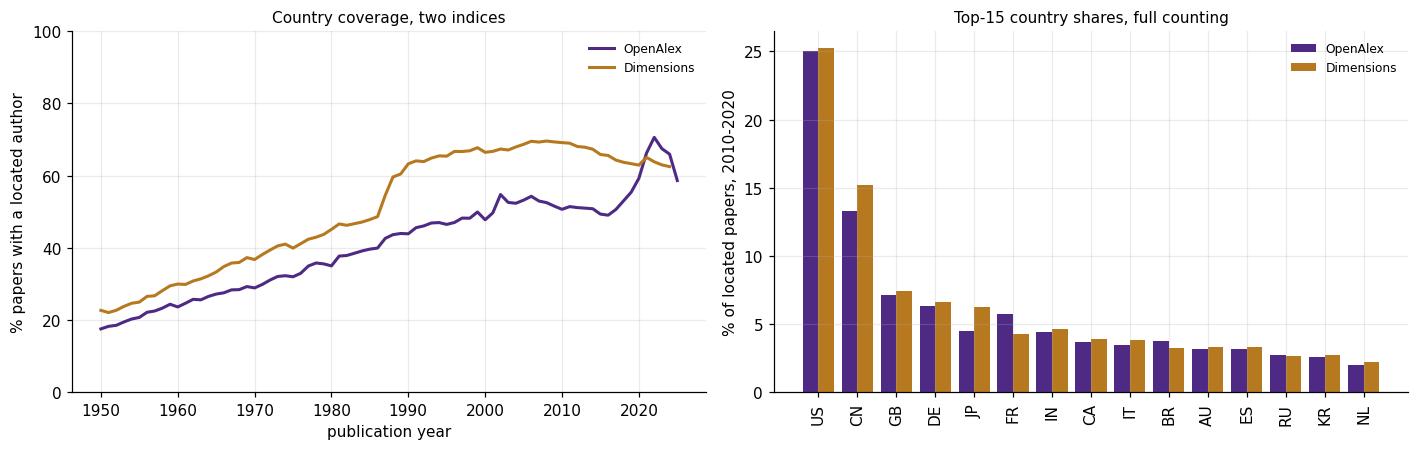

countries present in both: 223   Spearman of shares +0.978   Pearson +0.995
            oa    dim
country              
US       25.03  25.22
CN       13.32  15.21
GB        7.15   7.40
DE        6.35   6.62
JP        4.50   6.26
FR        5.72   4.25
IN        4.41   4.62
CA        3.66   3.92
IT        3.47   3.83
BR        3.79   3.24
AU        3.19   3.33
ES        3.20   3.29
RU        2.69   2.63
KR        2.58   2.71
NL        2.02   2.19
CPU times: user 1min 19s, sys: 4.59 s, total: 1min 23s
Wall time: 18 s


In [9]:
%%time
if not (os.path.exists(DIM_AU) and os.path.exists(DIM_META)):
    print('[skip 7] Dimensions paper_author / paper_metadata not present')
else:
    dcov = con.execute(f"""
    SELECT m.year::INTEGER AS year, count(*) AS n, 100.0*count(a.countries)/count(*) AS pct
    FROM read_parquet('{DIM_AU}') a JOIN read_parquet('{DIM_META}') m USING (paper_id)
    WHERE m.year BETWEEN {YMIN} AND 2024 GROUP BY 1 ORDER BY 1""").fetchdf()
    dtop = con.execute(f"""
    WITH x AS (
      SELECT a.countries FROM read_parquet('{DIM_AU}') a JOIN read_parquet('{DIM_META}') m USING (paper_id)
      WHERE m.year BETWEEN 2010 AND 2020 AND a.countries IS NOT NULL)
    SELECT c AS country, 100.0*count(*)/(SELECT count(*) FROM x) AS share
    FROM x, unnest(str_split(countries, ';')) AS u(c) GROUP BY 1""").fetchdf()

    oa = (100 * full[full.year.between(2010, 2020)].groupby('country').n.sum() / max(n_loc_1020, 1)).rename('oa')
    cmp7 = pd.concat([oa, dtop.set_index('country').share.rename('dim')], axis=1).fillna(0)
    top = cmp7.sum(axis=1).nlargest(15).index

    fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
    ax[0].plot(cov_y.year, cov_y.pct_papers, color=C1, lw=2, label='OpenAlex')
    ax[0].plot(dcov.year, dcov.pct, color='#b7791f', lw=2, label='Dimensions')
    ax[0].set_ylim(0, 100); ax[0].set_xlabel('publication year')
    ax[0].set_ylabel('% papers with a located author'); ax[0].legend(frameon=False, fontsize=8); clean(ax[0])
    ax[0].set_title('Country coverage, two indices', fontsize=10)
    xs = np.arange(len(top))
    ax[1].bar(xs - 0.2, cmp7.loc[top, 'oa'], 0.4, color=C1, label='OpenAlex')
    ax[1].bar(xs + 0.2, cmp7.loc[top, 'dim'], 0.4, color='#b7791f', label='Dimensions')
    ax[1].set_xticks(xs); ax[1].set_xticklabels(top, rotation=90)
    ax[1].set_ylabel('% of located papers, 2010-2020'); ax[1].legend(frameon=False, fontsize=8); clean(ax[1])
    ax[1].set_title('Top-15 country shares, full counting', fontsize=10)
    V.save('7')
    both = cmp7[(cmp7.oa > 0) & (cmp7.dim > 0)]
    if len(both) > 2:
        print(f'countries present in both: {len(both)}   Spearman of shares {spearman(both.oa, both.dim):+.3f}   '
              f'Pearson {np.corrcoef(both.oa, both.dim)[0, 1]:+.3f}')
    print(cmp7.loc[top].round(2).to_string())

## 8. First and last author

Among papers with ≥ 2 authors whose **first and last author are both located**: the share whose
two country lists intersect, by year, and the most common cross-country first → last pairs in
2015–2020 (both ends single-country, so the pair is unambiguous).

This is the one section that does not depend on the paper-level country set. First and last
authorship carry role information in most fields — who did the work, who ran the lab — so a
falling same-country share is a statement about the structure of collaborations that §3 cannot
make: papers can become international at the margins while the two ends of the byline stay in
one place.

  [fig] author_country_validation_8.jpg + .pdf  (600 dpi)


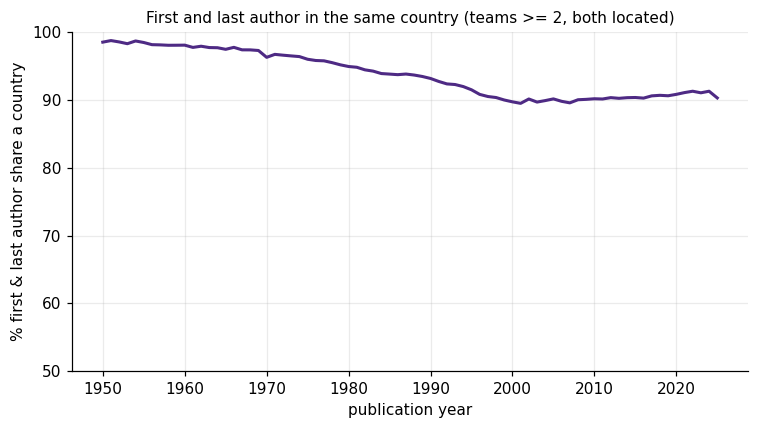

first_c last_c     n
     CN     US 57434
     GB     US 22306
     US     GB 21996
     CA     US 19343
     US     CA 17466
     CN     GB 14820
     US     CN 14133
     DE     US 13868
     CN     AU 12726
     US     DE 11510
     IT     US 10480
     FR     US  9988
     AU     US  9588
     IN     US  9487
     CN     HK  9396
CPU times: user 35.3 s, sys: 499 ms, total: 35.8 s
Wall time: 5.18 s


In [10]:
%%time
fl = con.execute(f"""
WITH x AS (
  SELECT year, str_split(first_author_country, ';') AS f, str_split(last_author_country, ';') AS l
  FROM {B}
  WHERE team_size >= 2 AND first_author_country IS NOT NULL AND last_author_country IS NOT NULL
    AND year BETWEEN {YMIN} AND {YMAX})
SELECT year, count(*) AS n, 100.0*avg(CASE WHEN len(list_intersect(f, l)) > 0 THEN 1.0 ELSE 0.0 END) AS same
FROM x GROUP BY 1 ORDER BY 1""").fetchdf()
flp = con.execute(f"""
SELECT first_author_country AS first_c, last_author_country AS last_c, count(*) AS n
FROM {B}
WHERE team_size >= 2 AND year BETWEEN 2015 AND 2020
  AND first_author_country IS NOT NULL AND last_author_country IS NOT NULL
  AND first_author_country <> last_author_country
  AND first_author_country NOT LIKE '%;%' AND last_author_country NOT LIKE '%;%'
GROUP BY 1, 2 ORDER BY 3 DESC LIMIT 15""").fetchdf()

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(fl.year, fl.same, color=C1, lw=2)
ax.set_xlabel('publication year'); ax.set_ylabel('% first & last author share a country')
ax.set_ylim(50, 100); clean(ax)
ax.set_title('First and last author in the same country (teams >= 2, both located)', fontsize=10)
V.save('8')
print(flp.to_string(index=False))

## 9. The world map

Four views of the same country table, on a Robinson projection.

1. **Share of world output**, fractional counting, 2015–2020, on a **log** colour scale. Output
   is distributed over roughly four orders of magnitude, so a linear ramp would paint every
   country except the United States and China the same shade.
2. **International collaboration rate** — the share of a country's located papers with authors
   in ≥ 2 countries. The expected pattern is small open economies dark and large self-sufficient
   producers light, which is close to the inverse of panel 1.
3. **Mean citation percentile**, 1990–2015 (closed 10-year windows), over countries with at
   least 1,000 scored papers.
4. **Change in share**, 2000–2005 → 2015–2020, as log₂ of the ratio: +1 is a doubled share of
   world output, −1 a halved one. Diverging scale, clipped at ±2, over countries with volume in
   both periods.

**Countries with no value are drawn in grey and are not zero** — panels 3 and 4 apply volume
floors, so grey there means "too few papers to say", not "no output". Every code in the data
that has no polygon is listed under the figure with the share of output it carries, so nothing
disappears silently.

  [fig] author_country_validation_9.jpg + .pdf  (600 dpi)


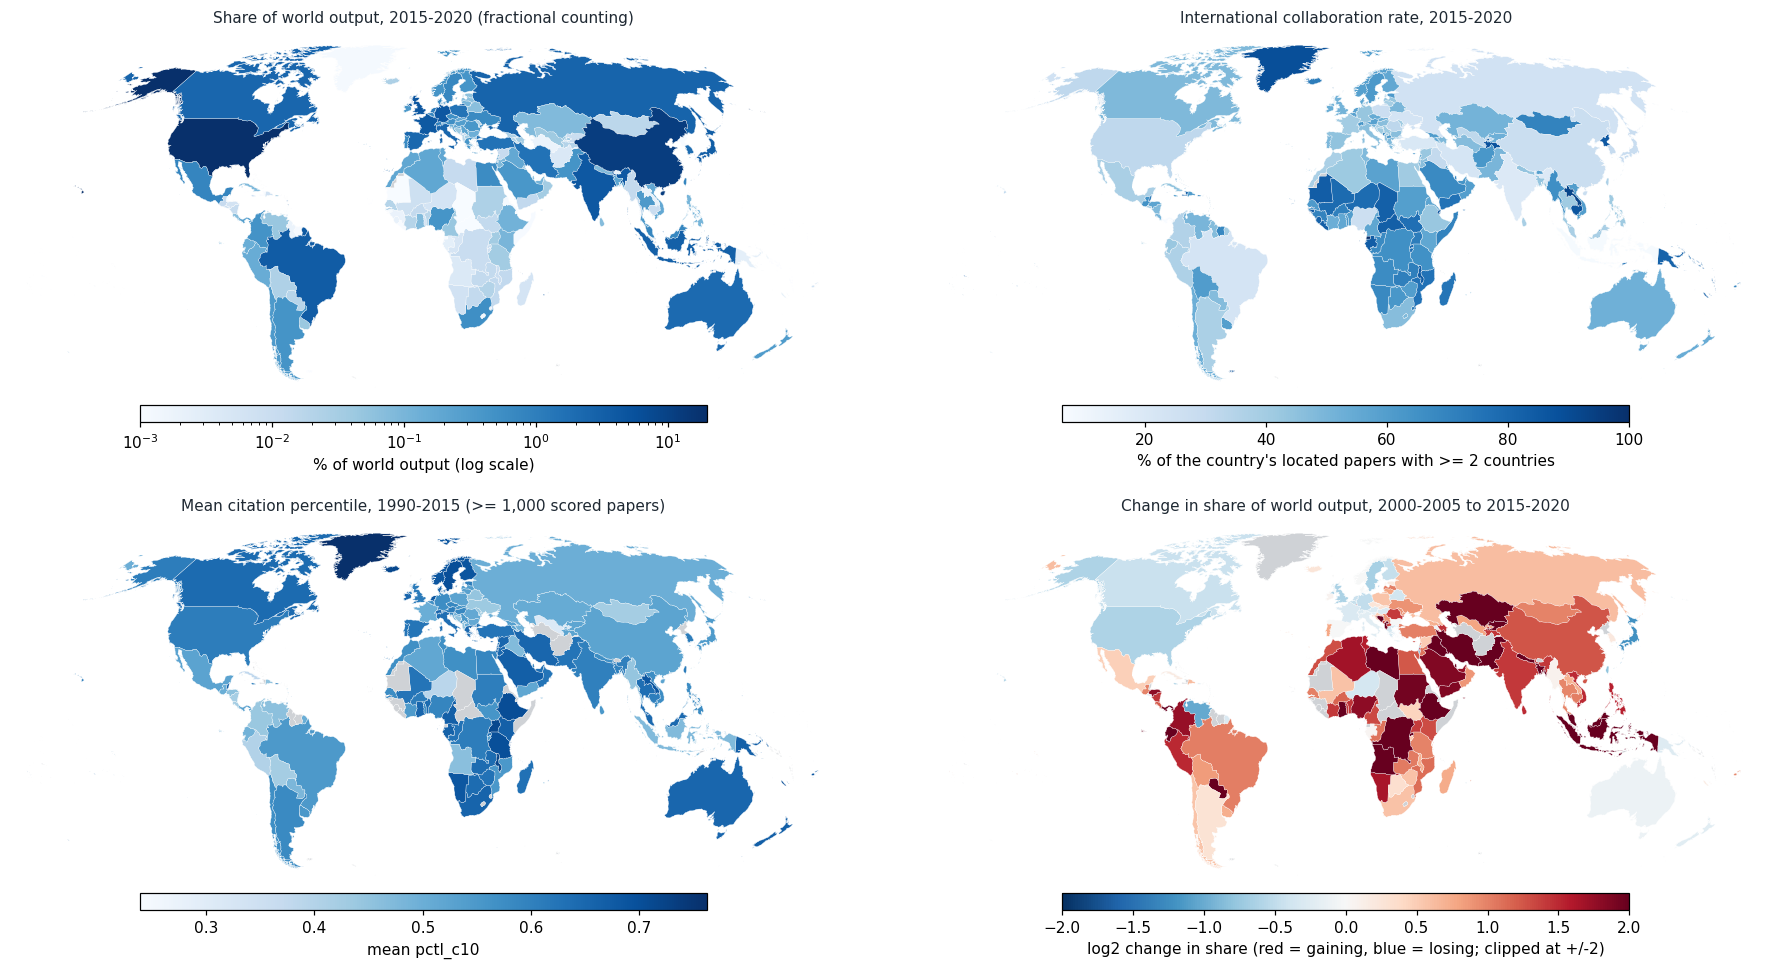

  9 author-country code(s) have no polygon on the map (0.02% of the total): BQ, GF, GI, GP, MQ, RE, SJ, UM, YT
  panel 3 covers 167 countries, panel 4 160
          share    intl    hit  change
country                               
US       19.701  31.826  0.608  -0.618
CN       11.807  27.649  0.524   1.265
GB        4.697  51.171  0.611  -0.638
DE        4.515  43.183  0.576  -0.497
IN        4.334  19.328  0.602   1.416
FR        4.094  40.274  0.502  -0.300
BR        3.613  23.018  0.549   1.017
JP        3.402  28.538  0.544  -1.206
ID        3.120   7.123  0.474   5.279
RU        2.704  24.427  0.500   0.614
IT        2.507  46.152  0.638  -0.225
CA        2.472  48.443  0.643  -0.452
ES        2.302  44.486  0.621  -0.014
AU        2.159  52.069  0.654  -0.111
KR        2.005  30.052  0.609   0.206
CPU times: user 23min 35s, sys: 7.39 s, total: 23min 43s
Wall time: 3min 42s


In [11]:
%%time
from matplotlib.colors import LogNorm, TwoSlopeNorm
world, PTS = load_world()
if world is None:
    print('[skip 9] no world geometry available')
else:
    cty = con.execute(f"""
    WITH x AS (
      SELECT year, n_countries, pctl_c10,
             list_transform(str_split(country_author_counts, ';'), s -> str_split(s, ':')) AS L
      FROM {B} WHERE country_author_counts IS NOT NULL AND year BETWEEN 1990 AND 2020),
    y AS (SELECT *, list_sum(list_transform(L, z -> z[2]::INTEGER)) AS tot FROM x)
    SELECT z[1] AS country,
           sum(CASE WHEN year BETWEEN 2015 AND 2020 THEN z[2]::INTEGER / tot END) AS frac_recent,
           sum(CASE WHEN year BETWEEN 2000 AND 2005 THEN z[2]::INTEGER / tot END) AS frac_early,
           count(*) FILTER (WHERE year BETWEEN 2015 AND 2020)                     AS n_recent,
           100.0*avg(CASE WHEN n_countries > 1 THEN 1.0 ELSE 0.0 END)
                 FILTER (WHERE year BETWEEN 2015 AND 2020)                        AS intl,
           avg(pctl_c10) FILTER (WHERE year BETWEEN 1990 AND 2015)                AS hit,
           count(pctl_c10) FILTER (WHERE year BETWEEN 1990 AND 2015)              AS n_hit
    FROM y, unnest(L) AS u(z) WHERE tot > 0 GROUP BY 1""").fetchdf().set_index('country')
    cty['share'] = 100 * cty.frac_recent / cty.frac_recent.sum()
    early = 100 * cty.frac_early / cty.frac_early.sum()
    cty['change'] = np.log2(cty.share / early)
    solid = cty[(cty.n_recent >= 1000) & (cty.frac_early >= 50)]

    fig, axes = plt.subplots(2, 2, figsize=(17, 9))
    choropleth(axes[0, 0], world, cty.share, 'Share of world output, 2015-2020 (fractional counting)',
               '% of world output (log scale)',
               norm=LogNorm(vmin=max(cty.share[cty.share > 0].min(), 1e-3), vmax=cty.share.max()))
    choropleth(axes[0, 1], world, cty.intl, 'International collaboration rate, 2015-2020',
               '% of the country\'s located papers with >= 2 countries')
    choropleth(axes[1, 0], world, cty.hit[cty.n_hit >= 1000],
               'Mean citation percentile, 1990-2015 (>= 1,000 scored papers)', 'mean pctl_c10')
    choropleth(axes[1, 1], world, solid.change.clip(-2, 2),
               'Change in share of world output, 2000-2005 to 2015-2020',
               'log2 change in share (red = gaining, blue = losing; clipped at +/-2)',
               cmap=DIV, norm=TwoSlopeNorm(vcenter=0, vmin=-2, vmax=2))
    V.save('9')
    map_coverage(cty.frac_recent.dropna(), world, 'author-country')
    print(f'  panel 3 covers {int((cty.n_hit >= 1000).sum())} countries, panel 4 {len(solid)}')
    print(cty.loc[cty.share.nlargest(15).index, ['share', 'intl', 'hit', 'change']].round(3).to_string())

## 10. Where the collaboration actually goes

The 70 largest country pairs of 2015–2020 drawn as great-circle arcs, width proportional to the
square root of the number of joint papers. §5 gives the same data exactly, as a matrix; this
gives it the one thing a matrix cannot, which is distance. Read the two together: the matrix is
where the numbers are, the map is where the structure is.

  [fig] author_country_validation_10.jpg + .pdf  (600 dpi)


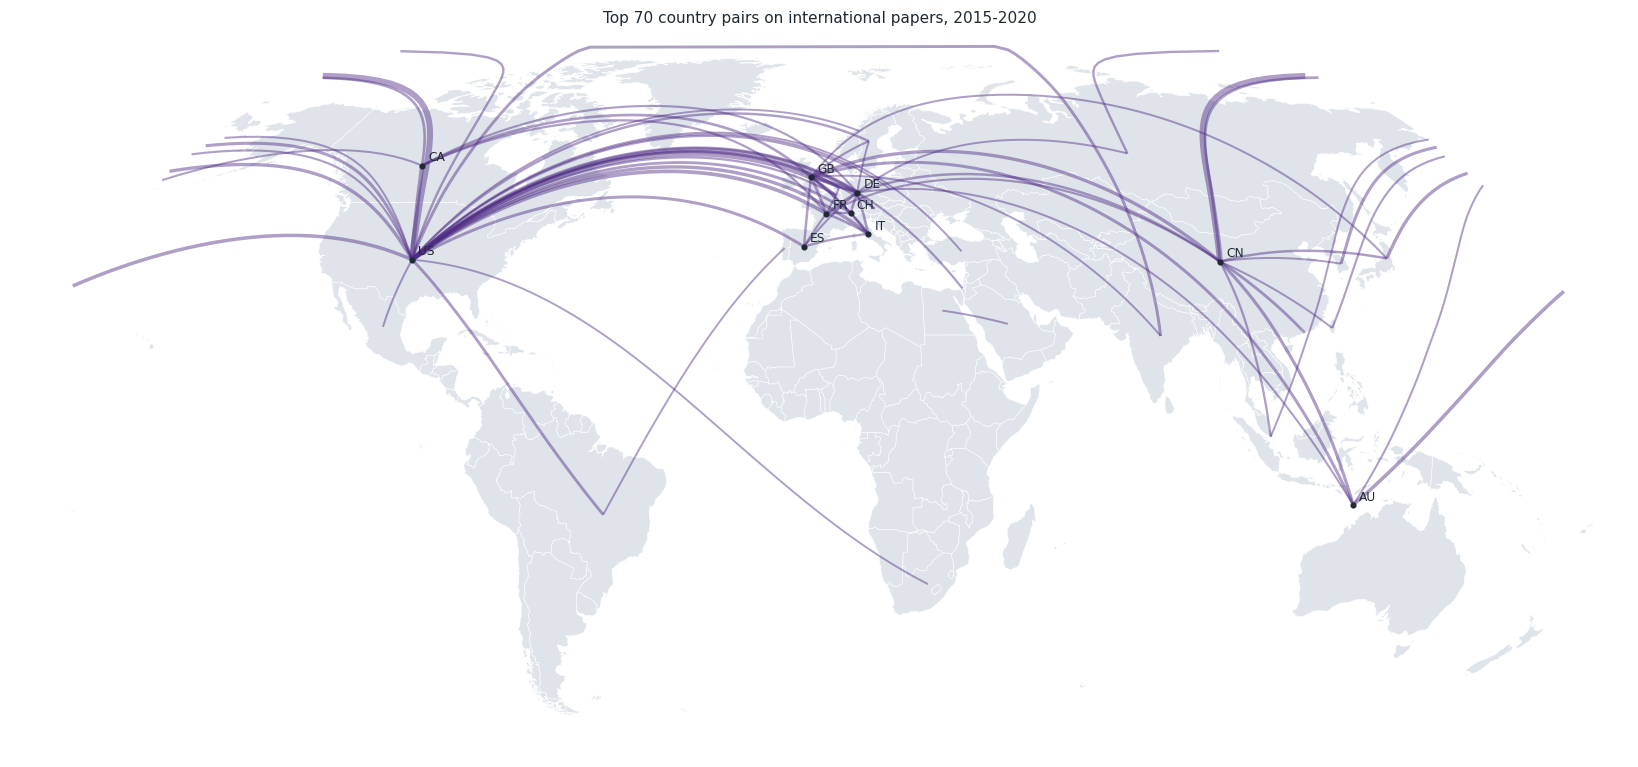

  the 70 arcs drawn carry 45.7% of all 8,352,984 country-pair occurrences in 2015-2020


CPU times: user 1.88 s, sys: 277 ms, total: 2.16 s
Wall time: 2.2 s


In [12]:
%%time
if world is None or not len(pairs):
    print('[skip 10] no world geometry or no pairs')
else:
    fig, ax = plt.subplots(figsize=(15, 7.5))
    flowmap(ax, world, PTS, pairs, 'Top 70 country pairs on international papers, 2015-2020')
    V.save('10')
    tot = pairs.n.sum()
    print(f'  the 70 arcs drawn carry {100*pairs.nlargest(70, "n").n.sum()/tot:.1f}% of all '
          f'{tot:,} country-pair occurrences in 2015-2020')
con.close()